In [ ]:
from pprint import pprint

import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.datasets import load_digits, make_moons
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Moons dataset
X_moons, y_moons = make_moons(n_samples=3000, noise=0.25, random_state=42)

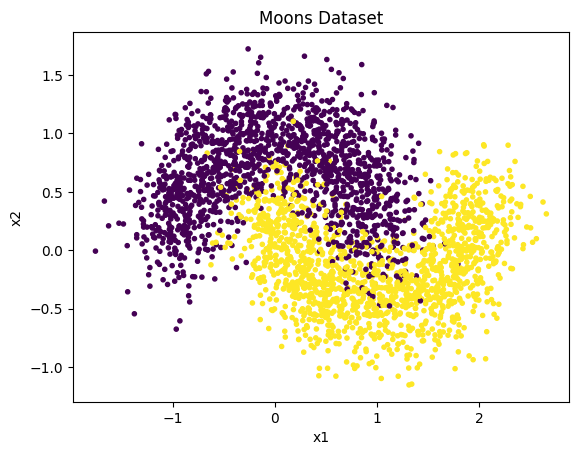

In [ ]:
# Visualize the dataset
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, marker=".")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)

In [ ]:
# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build the model
model = keras.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# Train the model
early_stopping = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    callbacks=[early_stopping],
)

Epoch 1/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6687 - loss: 0.5550 - val_accuracy: 0.8188 - val_loss: 0.4729
Epoch 2/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.4388 - val_accuracy: 0.8271 - val_loss: 0.3942
Epoch 3/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8552 - loss: 0.3654 - val_accuracy: 0.8396 - val_loss: 0.3553
Epoch 4/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8583 - loss: 0.3326 - val_accuracy: 0.8458 - val_loss: 0.3425
Epoch 5/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8630 - loss: 0.3204 - val_accuracy: 0.8479 - val_loss: 0.3380
Epoch 6/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8641 - loss: 0.3129 - val_accuracy: 0.8479 - val_loss: 0.3320
Epoch 7/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8651 - loss: 0.3051 - val_accuracy: 0.8479 - val_loss: 0.3247
Epoch 8/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8682 - loss: 0.2971 - val_accuracy: 0.8542 - v

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9467 - loss: 0.1409 
Test loss: 0.1409
Test accuracy: 0.9467


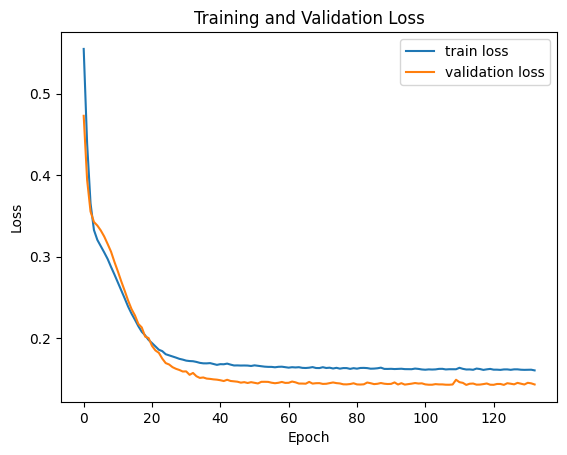

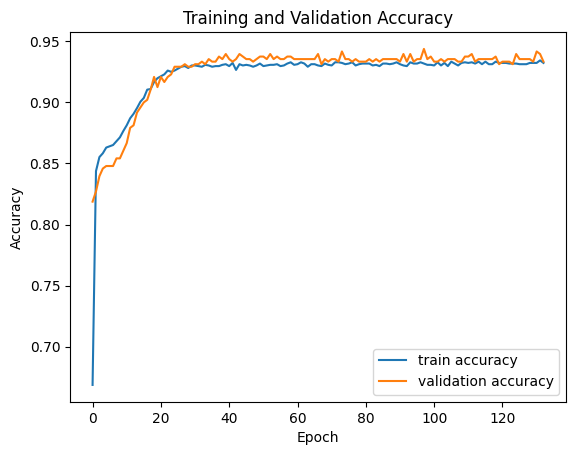

In [ ]:
# Plot training history
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

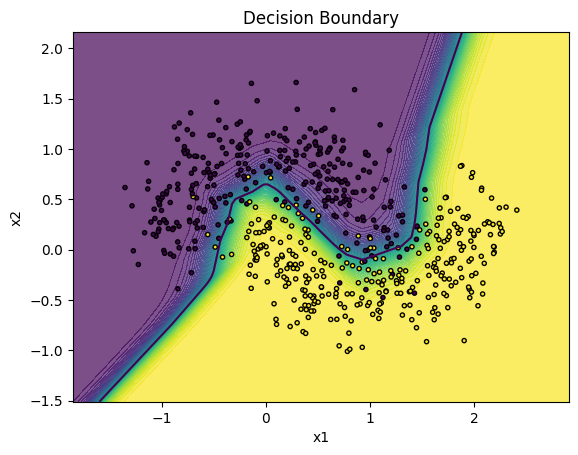

In [ ]:
# Plot decision boundary
def plot_decision_boundary(model, X, y, scaler):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)

    probabilities = model.predict(grid_scaled, verbose=0)
    Z = probabilities.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=50, alpha=0.7)
    plt.contour(xx, yy, Z, levels=[0.5])
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", marker=".")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Decision Boundary")
    plt.show()


plot_decision_boundary(model, X_test, y_test, scaler)

In [ ]:
# Digits dataset
digits_dataset = load_digits()

X_digits = digits_dataset.data
y_digits = digits_dataset.target

X_digits.shape
y_digits.shape

(1797,)

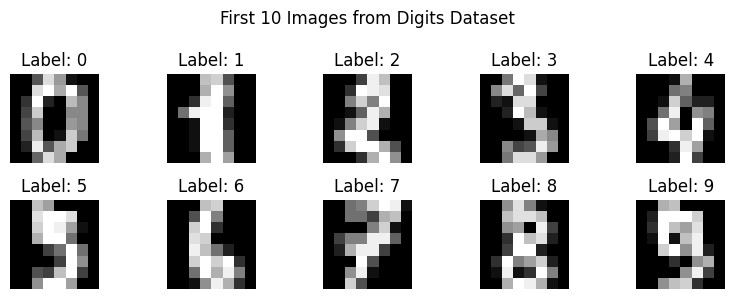

In [ ]:
# Visualize the first 10 images and their labels
plt.figure(figsize=(8, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits_dataset.images[i], cmap="gray")
    plt.title(f"Label: {y_digits[i]}")
    plt.axis("off")
plt.suptitle("First 10 Images from Digits Dataset")
plt.tight_layout()
plt.show()

In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42, stratify=y_digits
)

In [ ]:
# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build the model
model = keras.Sequential(
    [
        layers.Input(shape=(64,)),
        layers.Dense(
            128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
        ),
        layers.Dense(10, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
# Train the model
early_stopping = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[early_stopping],
)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1245 - loss: 2.4095 - val_accuracy: 0.2083 - val_loss: 2.2018
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2689 - loss: 1.9751 - val_accuracy: 0.4028 - val_loss: 1.8304
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5135 - loss: 1.6147 - val_accuracy: 0.5903 - val_loss: 1.5290
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6841 - loss: 1.3244 - val_accuracy: 0.6771 - val_loss: 1.2913
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7842 - loss: 1.0957 - val_accuracy: 0.7292 - val_loss: 1.1036
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8320 - loss: 0.9162 - val_accuracy: 0.7812 - val_loss: 0.9573
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8573 - loss: 0.7758 - val_accuracy: 0.8056 - val_loss: 0.8410
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8921 - loss: 0.6655 - val_accuracy: 0.8299 - val_loss:

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9833 - loss: 0.0680 
Test loss: 0.0680
Test accuracy: 0.9833


In [ ]:
# Predict
probs = model.predict(X_test_scaled)
predictions = np.argmax(probs, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


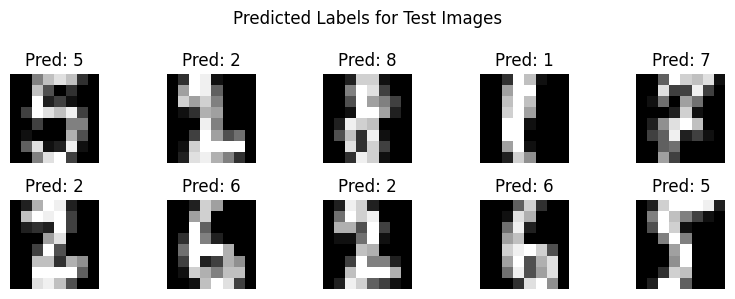

In [ ]:
# Visualize some predictions
plt.figure(figsize=(8, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title(f"Pred: {predictions[i]}")
    plt.axis("off")
plt.suptitle("Predicted Labels for Test Images")
plt.tight_layout()
plt.show()

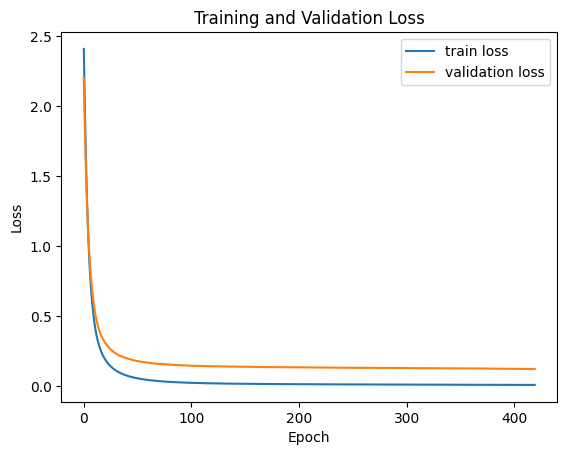

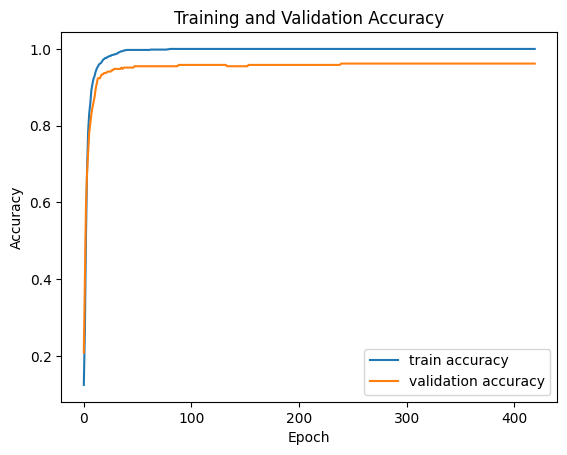

In [ ]:
# Plot training history
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

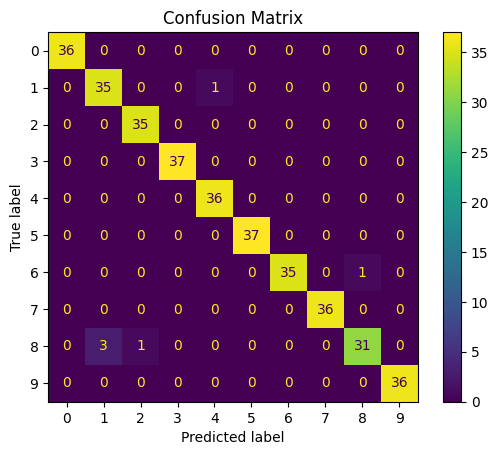

In [ ]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.summary()

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,832 (112.63 KB)

 Trainable params: 9,610 (37.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,222 (75.09 KB)

Training model with 32 units...
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0966 - loss: 2.6088 - val_accuracy: 0.1354 - val_loss: 2.4751
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1340 - loss: 2.4073 - val_accuracy: 0.1840 - val_loss: 2.2967
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1784 - loss: 2.2236 - val_accuracy: 0.2500 - val_loss: 2.1325
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2507 - loss: 2.0518 - val_accuracy: 0.3229 - val_loss: 1.9813
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3342 - loss: 1.8948 - val_accuracy: 0.4028 - val_loss: 1.8410
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4247 - loss: 1.7484 - val_accuracy: 0.4757 - val_loss: 1.7118
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5030 - loss: 1.6145 - val_accuracy: 0.5174 - val_loss: 1.5931
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5727 - loss: 1.4920 - 

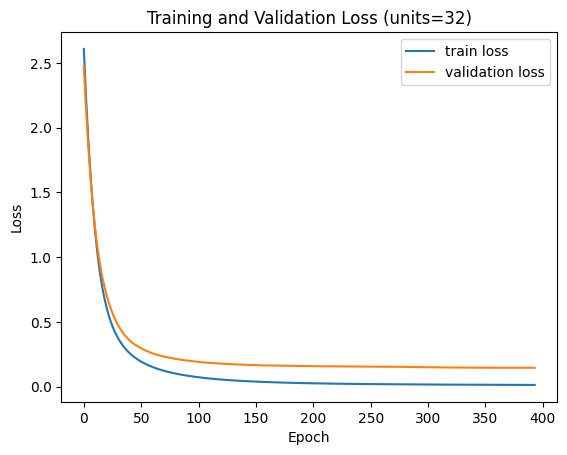

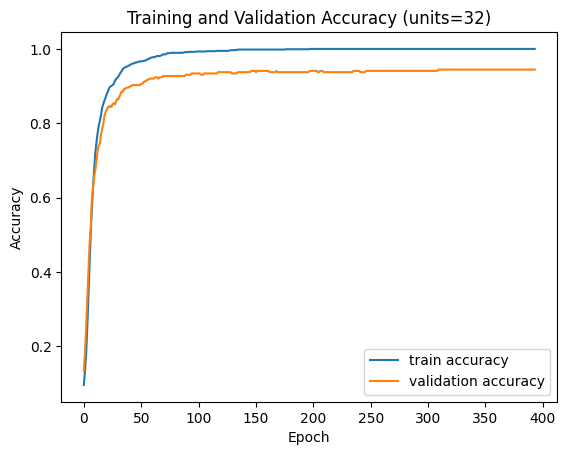

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


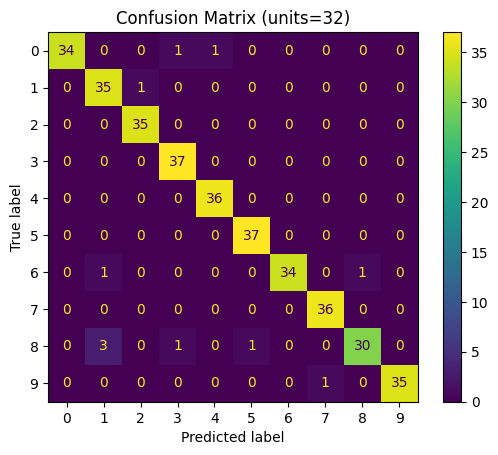

Training model with 64 units...
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1706 - loss: 2.4582 - val_accuracy: 0.1979 - val_loss: 2.3083
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2837 - loss: 2.1715 - val_accuracy: 0.2917 - val_loss: 2.0607
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3821 - loss: 1.9215 - val_accuracy: 0.3993 - val_loss: 1.8466
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4674 - loss: 1.7062 - val_accuracy: 0.4757 - val_loss: 1.6616
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5631 - loss: 1.5176 - val_accuracy: 0.5451 - val_loss: 1.4993
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6510 - loss: 1.3538 - val_accuracy: 0.6007 - val_loss: 1.3568
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7111 - loss: 1.2114 - val_accuracy: 0.6667 - val_loss: 1.2316
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7511 - loss: 1.0841 - 

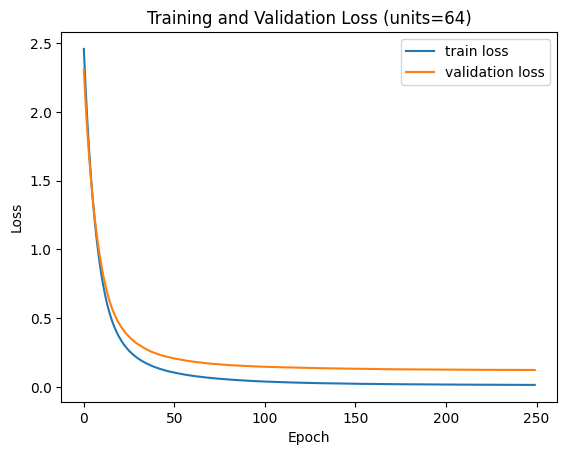

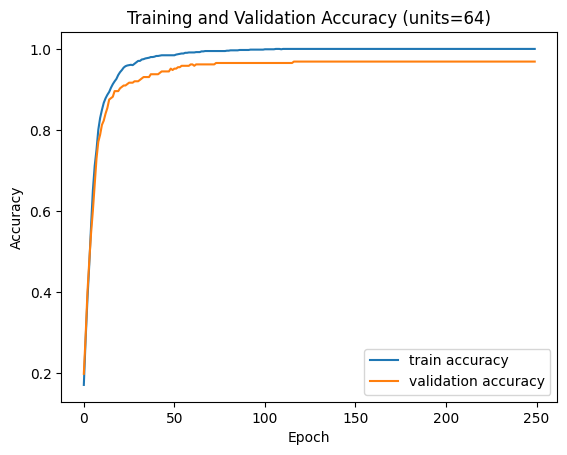

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


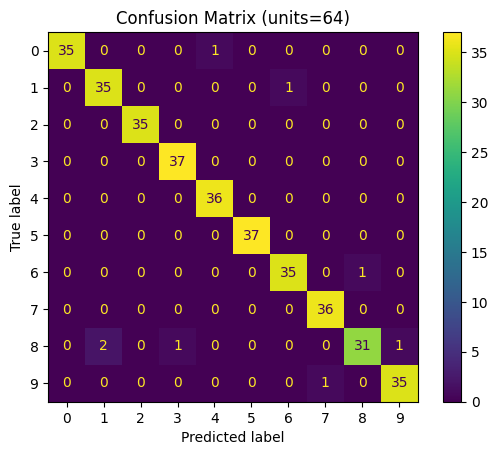

Training model with 128 units...
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1567 - loss: 2.3445 - val_accuracy: 0.2222 - val_loss: 2.0986
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3316 - loss: 1.9374 - val_accuracy: 0.4479 - val_loss: 1.7653
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5527 - loss: 1.5939 - val_accuracy: 0.6285 - val_loss: 1.4869
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7224 - loss: 1.3090 - val_accuracy: 0.7188 - val_loss: 1.2592
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8007 - loss: 1.0795 - val_accuracy: 0.7569 - val_loss: 1.0778
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8477 - loss: 0.9001 - val_accuracy: 0.7917 - val_loss: 0.9321
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8842 - loss: 0.7585 - val_accuracy: 0.8403 - val_loss: 0.8162
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9017 - loss: 0.6471 -

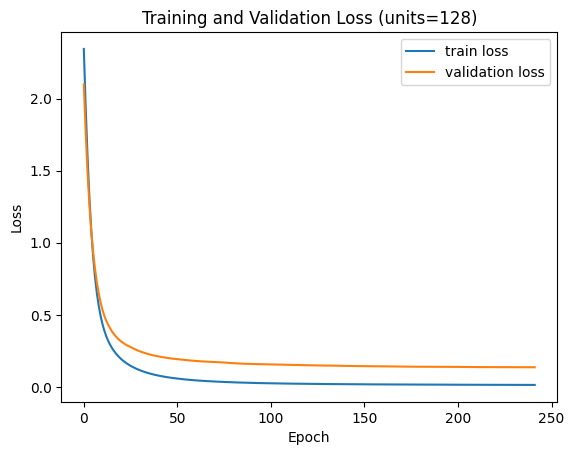

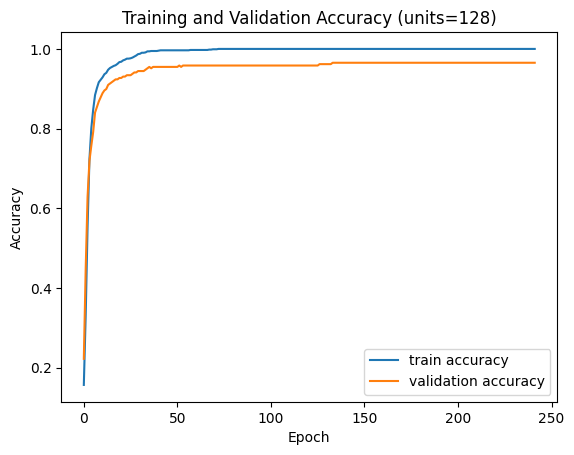

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


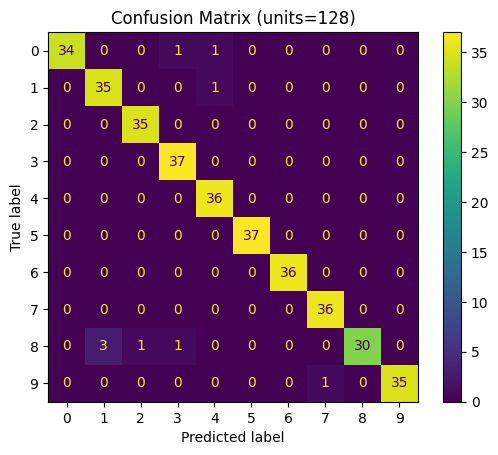

Training model with 256 units...
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1628 - loss: 2.3144 - val_accuracy: 0.3576 - val_loss: 1.9693
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5387 - loss: 1.7276 - val_accuracy: 0.6840 - val_loss: 1.5270
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7972 - loss: 1.2866 - val_accuracy: 0.7986 - val_loss: 1.1927
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8564 - loss: 0.9666 - val_accuracy: 0.8299 - val_loss: 0.9507
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8895 - loss: 0.7451 - val_accuracy: 0.8646 - val_loss: 0.7779
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9156 - loss: 0.5910 - val_accuracy: 0.8819 - val_loss: 0.6500
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9269 - loss: 0.4801 - val_accuracy: 0.8958 - val_loss: 0.5578
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9408 - loss: 0.4017 -

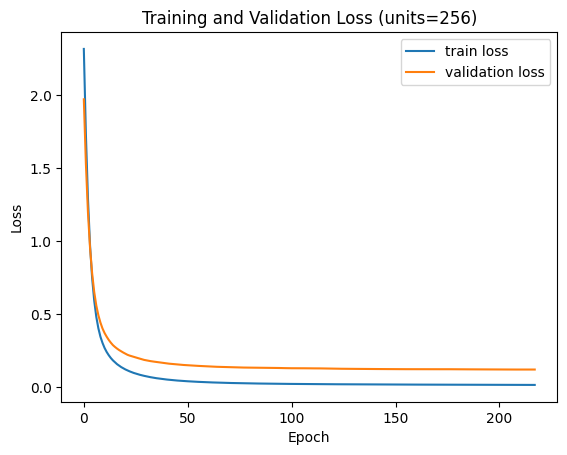

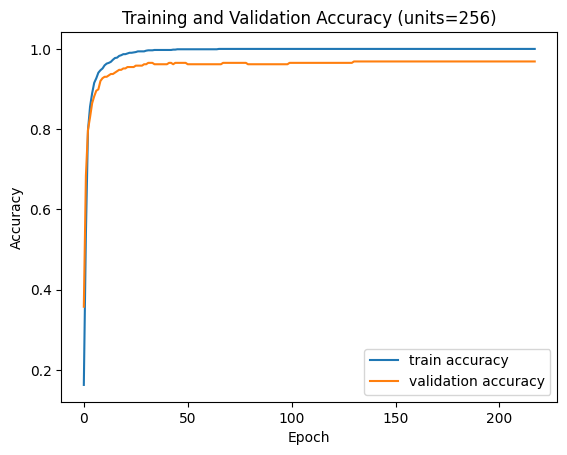

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


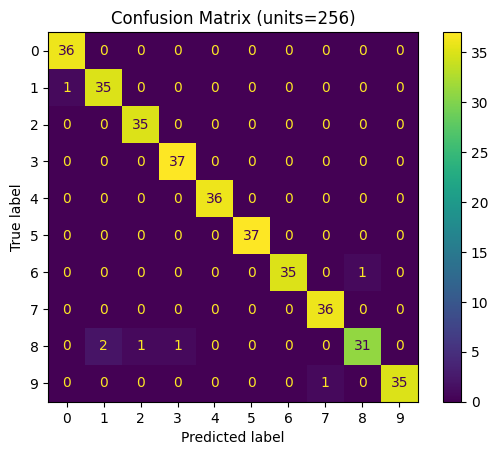

In [ ]:
# test with different units
def build_model(units):
    model = keras.Sequential(
        [
            layers.Input(shape=(64,)),
            layers.Dense(
                units, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)
            ),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
    )
    return model


units_list = [32, 64, 128, 256]
histories = []
eval_results = []

for units in units_list:
    print(f"Training model with {units} units...")
    model = build_model(units)
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=500,
        batch_size=256,
        callbacks=[early_stopping],
    )
    histories.append(history)
    test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
    results = {"units": units, "test_loss": test_loss, "test_accuracy": test_accuracy}
    eval_results.append(results)

    # Plot training history
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss (units={units})")
    plt.legend()
    plt.show()

    plt.plot(history.history["accuracy"], label="train accuracy")
    plt.plot(history.history["val_accuracy"], label="validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training and Validation Accuracy (units={units})")
    plt.legend()
    plt.show()

    # Confusion matrix
    probs = model.predict(X_test_scaled)
    predictions = np.argmax(probs, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_test, predictions)
    plt.title(f"Confusion Matrix (units={units})")
    plt.show()

In [ ]:
pprint(eval_results, indent=2, sort_dicts=False)

[ { 'units': 32,
    'test_loss': 0.11961928755044937,
    'test_accuracy': 0.9694444537162781},
  { 'units': 64,
    'test_loss': 0.12734201550483704,
    'test_accuracy': 0.9777777791023254},
  { 'units': 128,
    'test_loss': 0.13927112519741058,
    'test_accuracy': 0.9750000238418579},
  { 'units': 256,
    'test_loss': 0.08676141500473022,
    'test_accuracy': 0.980555534362793}]
